In [4]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

llm = ChatGroq(model="qwen/qwen3-32b")


In [5]:
## Custom tools
from langchain.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers and return the result.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The product of the two integers.
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """
    Add two integers and return the result.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The addition of the two integers.
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """
    Divide two integers and return the result.

    Args:
        a (int): The numerator.
        b (int): The denominator.

    Returns:
        float: The division result of a divided by b.
    """
    if b == 0:
        raise ArithmeticError("Denominator can't be zero.")

    return a / b

tools = [add, multiply, divide]

In [6]:
# Integrate custom tools with LLM
llm_with_tools = llm.bind_tools(tools=tools)

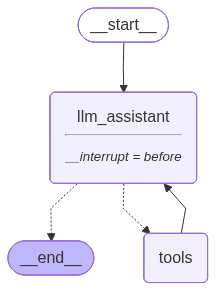

In [7]:
# Workflow with LangGraph
from IPython.display import Image, display

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain.messages import AIMessage, HumanMessage, SystemMessage


sys_message = SystemMessage(content="You are helpful assistant tasked with performing arithmetic on a set of inputs.")


# Node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_message] + state['messages'])]}


builder = StateGraph(MessagesState)

builder.add_node("llm_assistant", assistant)
builder.add_node("tools", ToolNode(tools=tools))


builder.add_edge(START, "llm_assistant")
builder.add_conditional_edges("llm_assistant", tools_condition)
builder.add_edge("tools", "llm_assistant")

memory = MemorySaver()

graph = builder.compile(interrupt_before=["llm_assistant"] ,checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))



In [8]:
config = {"configurable": {"thread_id": "thread-1"}}
initial_input = {"messages": HumanMessage(content="multiply 2 and 3")}

In [9]:
for event in graph.stream(initial_input, config=config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

multiply 2 and 3


In [10]:
state = graph.get_state(config=config)

In [11]:
print(state.next)

('llm_assistant',)


In [12]:
# Continue the execution
for event in graph.stream(None, config=config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (j7x1m1jq7)
 Call ID: j7x1m1jq7
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [13]:
graph.get_state(config=config).next

('llm_assistant',)

In [14]:
# Continue the execution
for event in graph.stream(None, config=config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is:

$$
6
$$


In [17]:
# Edit Human Feedback

initial_input = {"messages": HumanMessage(content="Multiply 5 and 10")}
config = {"configurable": {"thread_id": "test-thread"}}

for event in graph.stream(initial_input, config=config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 5 and 10


In [19]:
state = graph.get_state(config=config)
state.next

('llm_assistant',)

In [21]:
graph.update_state(config, {"messages": [HumanMessage(content="multiply 9 and 9")]})

{'configurable': {'thread_id': 'test-thread',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11e063-8042-613a-8001-038e3103a181'}}

In [26]:
new_state = graph.get_state(config=config)

values = new_state.values

for val in values['messages']:
    val.pretty_print()

================================ Human Message =================================

Multiply 5 and 10
================================ Human Message =================================

multiply 9 and 9


In [27]:
for event in graph.stream(None, config=config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

multiply 9 and 9
================================== Ai Message ==================================
Tool Calls:
  multiply (ccr6bbvmt)
 Call ID: ccr6bbvmt
  Args:
    a: 9
    b: 9
================================= Tool Message =================================
Name: multiply

81


In [28]:
for event in graph.stream(None, config=config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

81
================================== Ai Message ==================================

The result of multiplying 9 and 9 is **81**.
